In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import sys
sys.path.append('..')

from pathlib import Path
from pynwb import NWBHDF5IO
from gaussian_filtering import fit_gaussian_to_rf, get_rf_size_degrees

## Inspect NWB file

In [2]:
nwb_path = r"X:\Personnel\MaryBeth\OpenScope\001709\sub-815059\sub-815059_ses-multiplane-ophys-815059-2025-10-23-11-51-43_ophys.nwb"

with warnings.catch_warnings():
    warnings.filterwarnings("ignore", message="Ignoring cached namespace")
    io = NWBHDF5IO(nwb_path, "r", load_namespaces=True)
    nwb = io.read()

print(nwb)

root abc.NdxEventsNWBFile at 0x1477020660304
Fields:
  acquisition: {
    raw_running_wheel_rotation <class 'pynwb.base.TimeSeries'>,
    running_wheel_signal_voltage <class 'pynwb.base.TimeSeries'>,
    running_wheel_supply_voltage <class 'pynwb.base.TimeSeries'>
  }
  devices: {
    MESO.1 <class 'pynwb.device.Device'>
  }
  experimenter: ["['NSB-1007', 'Jerome Lecoq']"]
  file_create_date: [datetime.datetime(2026, 2, 3, 8, 51, 40, 904295, tzinfo=tzutc())]
  identifier: 40420797-235e-477f-83ff-3055d55ad972
  imaging_planes: {
    VISp_0 <class 'pynwb.ophys.ImagingPlane'>,
    VISp_1 <class 'pynwb.ophys.ImagingPlane'>,
    VISp_2 <class 'pynwb.ophys.ImagingPlane'>,
    VISp_3 <class 'pynwb.ophys.ImagingPlane'>,
    VISp_4 <class 'pynwb.ophys.ImagingPlane'>,
    VISp_5 <class 'pynwb.ophys.ImagingPlane'>,
    VISp_6 <class 'pynwb.ophys.ImagingPlane'>,
    VISp_7 <class 'pynwb.ophys.ImagingPlane'>
  }
  institution: Allen Institute for Neural Dynamics
  intervals: {
    drifting_gratings

In [ ]:
# Inspect RF stimulus table
rf_stim_table = nwb.intervals["receptive_field_block_presentations"].to_dataframe()

rf_stim_table['x_position'] = rf_stim_table['x_position'].astype(float)
rf_stim_table['y_position'] = rf_stim_table['y_position'].astype(float)

xs = np.sort(rf_stim_table.x_position.unique())
ys = np.sort(rf_stim_table.y_position.unique())

print(f"X positions: {xs}")
print(f"Y positions: {ys}")
print(f"Presentations per location: {rf_stim_table.groupby(['x_position','y_position']).size().unique()}")
print(f"Stim duration: {(rf_stim_table.stop_time - rf_stim_table.start_time).mean():.3f} s")

X positions: [-40. -30. -20. -10.   0.  10.  20.  30.  40.]
Y positions: [-40. -30. -20. -10.   0.  10.  20.  30.  40.]
Presentations per location: [30]
Stim duration: 0.250 s


In [4]:
print(rf_stim_table)

      start_time  stop_time              stim_name    stim_type stim_block  \
id                                                                           
0       18.65377   18.90399  receptive_field_block  GratingStim        0.0   
1       18.90399   19.15421  receptive_field_block  GratingStim        0.0   
2       19.15421   19.40441  receptive_field_block  GratingStim        0.0   
3       19.40441   19.65464  receptive_field_block  GratingStim        0.0   
4       19.65464   19.90483  receptive_field_block  GratingStim        0.0   
...          ...        ...                    ...          ...        ...   
2425   625.46659  625.71679  receptive_field_block  GratingStim        0.0   
2426   625.71679  625.96706  receptive_field_block  GratingStim        0.0   
2427   625.96706  626.21724  receptive_field_block  GratingStim        0.0   
2428   626.21724  626.46745  receptive_field_block  GratingStim        0.0   
2429   626.46745  626.71769  receptive_field_block  GratingStim 

In [5]:
planes = [k for k in nwb.processing.keys() if k.startswith('VISp_')]
print(planes)

['VISp_0', 'VISp_1', 'VISp_2', 'VISp_3', 'VISp_4', 'VISp_5', 'VISp_6', 'VISp_7']


global_roi_ids shape: (153,)
image_masks shape: (153, 512, 512)


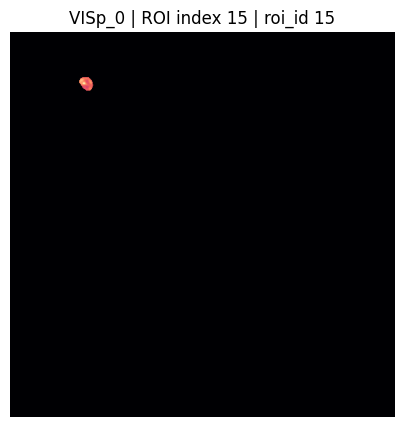

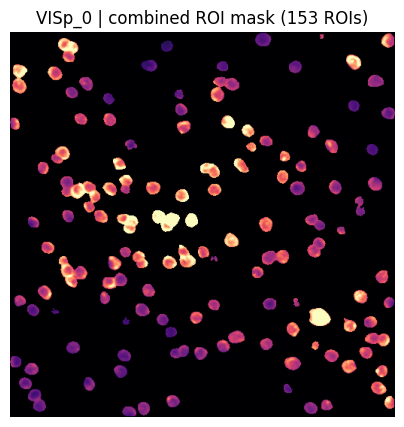

In [6]:
plane = 'VISp_0'
mod = nwb.processing[plane]

roi_table = mod['image_segmentation'].plane_segmentations['roi_table']
global_roi_ids = roi_table.id[:]
print(f"global_roi_ids shape: {global_roi_ids.shape}")

image_masks = roi_table['image_mask'][:]
print(f"image_masks shape: {image_masks.shape}")

# Show a single ROI mask
roi_idx = 15 
plt.figure(figsize=(5, 5))
plt.imshow(image_masks[roi_idx], cmap='magma')
plt.title(f"{plane} | ROI index {roi_idx} | roi_id {global_roi_ids[roi_idx]}")
plt.axis('off')
plt.show()

# Show union of all ROI masks
combined_mask = np.max(image_masks, axis=0)
plt.figure(figsize=(5, 5))
plt.imshow(combined_mask, cmap='magma')
plt.title(f"{plane} | combined ROI mask ({len(global_roi_ids)} ROIs)")
plt.axis('off')
plt.show()

In [7]:
print(mod)

VISp_0 pynwb.base.ProcessingModule at 0x1477020661840
Fields:
  data_interfaces: {
    dff_timeseries <class 'pynwb.ophys.DfOverF'>,
    event_timeseries <class 'pynwb.ophys.RoiResponseSeries'>,
    image_segmentation <class 'pynwb.ophys.ImageSegmentation'>,
    images <class 'pynwb.base.Images'>,
    neuropil_corrected_timeseries <class 'pynwb.ophys.RoiResponseSeries'>,
    neuropil_fluorescence_timeseries <class 'pynwb.ophys.RoiResponseSeries'>,
    raw_timeseries <class 'pynwb.ophys.Fluorescence'>
  }



In [8]:
dff_timeseries = mod['dff_timeseries']
print(dff_timeseries)

dff_timeseries pynwb.ophys.DfOverF at 0x1477020662320
Fields:
  roi_response_series: {
    dff_timeseries <class 'pynwb.ophys.RoiResponseSeries'>
  }



In [9]:
event_timeseries  = mod['event_timeseries']
print(event_timeseries)

event_timeseries pynwb.ophys.RoiResponseSeries at 0x1477020662656
Fields:
  comments: no comments
  conversion: 1.0
  data: <HDF5 dataset "data": shape (38455, 153), type "<f4">
  description: no description
  interval: 1
  offset: 0.0
  resolution: -1.0
  rois: rois <class 'hdmf.common.table.DynamicTableRegion'>
  timestamps: <HDF5 dataset "timestamps": shape (38455,), type "<f8">
  timestamps_unit: seconds
  unit: a.u.



In [14]:
raw_timeseries   = mod['raw_timeseries']
print(raw_timeseries)

raw_timeseries_trace = mod['raw_timeseries'].roi_response_series['ROI_fluorescence_timeseries'].data[:]
print(raw_timeseries_trace)

raw_timeseries pynwb.ophys.Fluorescence at 0x1477020833472
Fields:
  roi_response_series: {
    ROI_fluorescence_timeseries <class 'pynwb.ophys.RoiResponseSeries'>
  }

[[555.1839  746.7569  913.73755 ... 581.74194 712.4525  627.3618 ]
 [602.06506 876.054   818.72644 ... 743.33386 699.85504 664.7112 ]
 [586.8287  764.20306 814.2126  ... 624.0871  723.0015  647.0026 ]
 ...
 [691.08344 889.5082  578.4735  ... 727.40314 732.6614  688.4561 ]
 [722.72864 918.85724 718.99927 ... 712.46027 726.53046 689.9143 ]
 [629.25397 842.49963 737.9433  ... 628.74066 723.4661  705.1841 ]]


## Write function to get ophys traces

In [ ]:
def get_ophys_traces(nwb, plane_names=None):
    if plane_names is None:
        plane_names = [k for k in nwb.processing.keys() if k.startswith('VISp_')]
    
    all_traces = []
    all_roi_info = []
    
    for plane_name in plane_names:
        mod = nwb.processing[plane_name]
        
        series = mod['dff_timeseries'].roi_response_series['dff_timeseries']
        traces_plane = series.data[:]
        plane_timestamps = series.timestamps[:]

        roi_table = mod['image_segmentation'].plane_segmentations['roi_table']
        global_roi_ids = roi_table.id[:]

        all_traces.append(traces_plane)
        for local_idx, roi_id in enumerate(global_roi_ids):
            all_roi_info.append({
                'roi_id': f"{plane_name}_roi{roi_id}",
                'plane': plane_name,
                'local_roi_index': local_idx,
                'raw_roi_id': roi_id,
                'timestamps': plane_timestamps,  
            })

    combined_traces = np.concatenate(all_traces, axis=1)
    roi_info = pd.DataFrame(all_roi_info)
    timestamps = roi_info.iloc[0]['timestamps']

    return combined_traces, timestamps, roi_info

## Write function to build RF

In [18]:
def get_rf(xs, ys, rf_stim_table, orientation=None, timestamps=None, responses=None,
           t_start=0.05, t_end=0.25):
    
    # create empty array
    unit_rf = np.zeros([ys.size, xs.size])
    # loop over every x position
    for xi, x in enumerate(xs):
        # loop over every y position
        for yi, y in enumerate(ys):
            
            # get all stimulus presentations for this position
            stim_rows = rf_stim_table[(rf_stim_table.x_position == x) & (rf_stim_table.y_position == y)]
            
            if orientation is not None:
                stim_rows = stim_rows[stim_rows.orientation == orientation]
            
            # start with an empty mask for all time points
            all_mask = np.zeros(len(timestamps), dtype=bool)
            
            # loop over each stimulus presentation and build a mask of time points that fall within the response window
            for _, row in stim_rows.iterrows():
                all_mask |= (timestamps >= row.start_time + t_start) & (timestamps < row.start_time + t_end)
            
            # average the df/F values that fall within the response windows marked as true
            unit_rf[yi, xi] = np.mean(responses[all_mask]) if all_mask.any() else np.nan
          
    return unit_rf

def get_rf_with_baseline(xs, ys, rf_stim_table, orientation=None, timestamps=None, responses=None,
           t_start=0.1, t_end=0.6,
           baseline_start=-0.2, baseline_end=0.0):
    """
    Build a spatial RF map by averaging dF/F within a response window relative
    to stimulus onset, with optional pre-stimulus baseline subtraction.

    Parameters
    ----------
    t_start, t_end : float
        Response window relative to stimulus onset (seconds).
        FIX: widened from (0.05, 0.25) to (0.1, 0.6) to capture the GCaMP
        transient, which typically peaks 300-700ms post-stimulus.
    baseline_start, baseline_end : float
        Pre-stimulus window for baseline subtraction (seconds relative to onset).
        FIX: added baseline subtraction to remove trial-by-trial DC offsets.
    """
    unit_rf = np.zeros([ys.size, xs.size])

    for xi, x in enumerate(xs):
        for yi, y in enumerate(ys):

            stim_rows = rf_stim_table[
                (rf_stim_table.x_position.astype(float) == x) &
                (rf_stim_table.y_position.astype(float) == y)
            ]
            if orientation is not None:
                stim_rows = stim_rows[stim_rows.orientation == orientation]

            trial_responses = []
            for _, row in stim_rows.iterrows():
                t0 = row.start_time

                # response window
                resp_mask = (timestamps >= t0 + t_start) & (timestamps < t0 + t_end)
                if not resp_mask.any():
                    continue

                # FIX: baseline subtraction — mean dF/F in pre-stim window
                base_mask = (timestamps >= t0 + baseline_start) & (timestamps < t0 + baseline_end)
                baseline = np.mean(responses[base_mask]) if base_mask.any() else 0.0

                trial_responses.append(np.mean(responses[resp_mask]) - baseline)

            unit_rf[yi, xi] = np.mean(trial_responses) if trial_responses else 0.0

    return unit_rf

def get_rf_with_shuffle_test(xs, ys, rf_stim_table, timestamps, responses,
                               t_start=0.05, t_end=0.25, n_shuffles=500, alpha=0.05):
    unit_rf = np.full([ys.size, xs.size], np.nan)
    for xi, x in enumerate(xs):
        for yi, y in enumerate(ys):
            stim_rows = rf_stim_table[(rf_stim_table.x_position == x) & (rf_stim_table.y_position == y)]
            all_mask = np.zeros(len(timestamps), dtype=bool)
            for _, row in stim_rows.iterrows():
                all_mask |= (timestamps >= row.start_time + t_start) & (timestamps < row.start_time + t_end)
            if not all_mask.any():
                continue
            observed = np.mean(responses[all_mask])
            n_samples = all_mask.sum()
            # null distribution: random time windows of the same size
            shuffled_means = [np.mean(responses[np.random.choice(len(responses), n_samples, replace=False)])
                               for _ in range(n_shuffles)]
            p_val = np.mean(np.array(shuffled_means) >= observed)
            unit_rf[yi, xi] = observed if p_val < alpha else np.nan
    return unit_rf

## Test on single unit

(38455,)
[696.89734 674.3208  771.7872  ... 934.4604  880.347   858.25116]
(38455,)
[  18.10151   18.207     18.31249 ... 4074.90612 4075.01163 4075.11713]


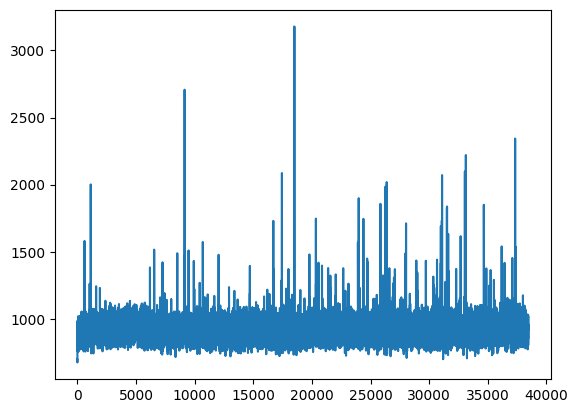

In [ ]:
plane = "VISp_0"
mod = nwb.processing[plane]

trace = mod['raw_timeseries'].roi_response_series['ROI_fluorescence_timeseries'].data[:]

random_index = np.random.randint(trace.shape[1])

single_trace = trace[:,random_index]
print(single_trace.shape)
print(single_trace)

plt.plot(single_trace)

timestamps = mod['raw_timeseries'].roi_response_series['ROI_fluorescence_timeseries'].timestamps[:]
print(timestamps.shape)
print(timestamps)

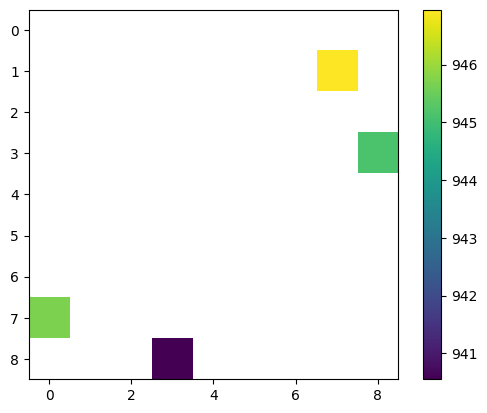

In [31]:
rf = get_rf_with_shuffle_test(xs, ys, rf_stim_table, timestamps, single_trace,
                               t_start=0.05, t_end=0.25, n_shuffles=500, alpha=0.05)

plt.imshow(rf)
plt.colorbar()
plt.show()

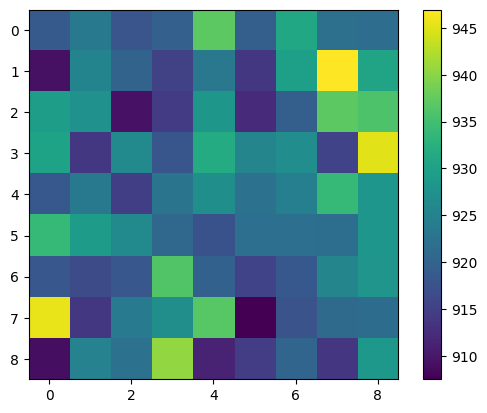

In [32]:
rf = get_rf(xs, ys, rf_stim_table, orientation=None, timestamps=timestamps, responses=single_trace,
            t_start=0.05, t_end=0.25)

plt.imshow(rf)
plt.colorbar()
plt.show()

## Build RFs for all mice

In [ ]:
data_dir = Path(r"X:\Personnel\MaryBeth\OpenScope\001709")
output_dir = Path(r"C:\Users\MaryBeth\projects\SarvestaniLab\OpenScopeMouseV1\jupyternotebooks\ophys\results")

mouse_dirs = [d for d in data_dir.iterdir() if d.is_dir() and d.name.startswith('sub-')]
print(f"Found {len(mouse_dirs)} mouse directories")

In [ ]:
baseline = False

unit_records_all = []

for mouse_idx, mouse_dir in enumerate(mouse_dirs, 1):
    mouse_name = mouse_dir.name
    print("=" * 80)
    print(f"Processing Mouse {mouse_idx}/{len(mouse_dirs)}: {mouse_name}")
    print("=" * 80)

    nwb_files = list(mouse_dir.glob("*.nwb"))
    if not nwb_files:
        print(f"  No NWB files found in {mouse_dir}, skipping.")
        continue

    for nwb_path in nwb_files:
        print(f"  Processing NWB file: {nwb_path.name}")
        io = None
        try:
            io = NWBHDF5IO(str(nwb_path), "r", load_namespaces=True)
            nwb = io.read()

            traces, timestamps, roi_info = get_ophys_traces(nwb)
            print(f"  traces shape: {traces.shape}, timestamps: {timestamps[0]:.2f} → {timestamps[-1]:.2f}")

            # RF block
            print(f"  Computing RFs...")
            # rf_stim_table = nwb.intervals["receptive_field_block_presentations"].to_dataframe()
            # xs = np.sort(np.array(list(set(rf_stim_table.x_position.astype(float)))))
            # ys = np.sort(np.array(list(set(rf_stim_table.y_position.astype(float)))))

            rf_stim_table = nwb.intervals["receptive_field_block_presentations"].to_dataframe()

            # cast position columns to float once, so all downstream comparisons are numeric
            rf_stim_table['x_position'] = rf_stim_table['x_position'].astype(float)
            rf_stim_table['y_position'] = rf_stim_table['y_position'].astype(float)

            xs = np.sort(rf_stim_table.x_position.unique())
            ys = np.sort(rf_stim_table.y_position.unique())

            uid_to_rf = {}

            for col_idx, (local_idx, row) in enumerate(roi_info.iterrows()):
                uid = row['roi_id']
                plane = row['plane']
                dff_trace = traces[:, col_idx]

                # use per-plane timestamps for this ROI
                plane_timestamps = row['timestamps']

                orientations = [None] + list(rf_stim_table.orientation.unique())
                for ori in orientations:
                    ori_label = str(ori) if ori is not None else 'all'

                    if not baseline:
                       rf = get_rf(xs=xs, ys=ys, timestamps=plane_timestamps,
                                    rf_stim_table=rf_stim_table,
                                    orientation=ori, responses=dff_trace)
                       save_dir = mouse_dir / 'RFs' / nwb_path.stem / plane / ori_label
                    # if not baseline:
                    #     rf = get_rf_with_shuffle_test(xs=xs, ys=ys, rf_stim_table=rf_stim_table,
                    #            timestamps=plane_timestamps, responses=dff_trace,
                    #            t_start=0.05, t_end=0.25, n_shuffles=500, alpha=0.05)
                    #     save_dir = mouse_dir / 'RFs' / nwb_path.stem / plane / ori_label
                    else: 
                        rf = get_rf_with_baseline(xs=xs, ys=ys, timestamps=plane_timestamps,
                                     rf_stim_table=rf_stim_table,
                                     orientation=ori, responses=dff_trace)
                        save_dir = mouse_dir / 'RFs_with_baseline' / nwb_path.stem / plane / ori_label

                    # store each (unit, orientation) separately
                    uid_to_rf[(uid, ori_label)] = {'rf': rf, 'xs': xs, 'ys': ys}

                    
                    save_dir.mkdir(parents=True, exist_ok=True)

                    popt, r_squared, _ = fit_gaussian_to_rf(rf)
                    if popt is not None:
                        x_pos = float(np.interp(popt[1], np.arange(len(xs)), xs))
                        y_pos = float(np.interp(popt[2], np.arange(len(ys)), ys))
                        fit_status = 'success'
                    else:
                        x_pos, y_pos = np.nan, np.nan
                        fit_status = 'failed'
                        print(f"  Fit failed for {uid} (orientation={ori_label})")

                    plt.imshow(rf, extent=(xs.min(), xs.max(), ys.min(), ys.max()), origin='lower')
                    plt.colorbar(label='dF/F')
                    plt.scatter(x_pos, y_pos, color='red', marker='x', label='RF Center')
                    plt.xlabel('X position (deg)')
                    plt.ylabel('Y position (deg)')
                    plt.title(f'{uid} ori={ori_label} (R²={r_squared:.3f})' if r_squared is not None else f'RF map: {uid} ori={ori_label} (no fit)')
                    plt.savefig(save_dir / f'RF_map_{uid}.png', dpi=150, bbox_inches='tight')
                    plt.close()

                    unit_records_all.append({
                        'roi_id': uid,
                        'mouse_name': mouse_name,
                        'nwb_file': nwb_path.name,
                        'plane': plane,
                        'orientation': ori_label,
                        'fit_status': fit_status,
                        'rf_center_x': x_pos if popt is not None else np.nan,
                        'rf_center_y': y_pos if popt is not None else np.nan,
                        'r_squared': float(r_squared) if popt is not None else np.nan,
                        'rf_amplitude': float(popt[0]) if popt is not None else np.nan,
                        'rf_sigma_x': float(popt[3]) if popt is not None else np.nan,
                        'rf_sigma_y': float(popt[4]) if popt is not None else np.nan,
                        'mean_dff': float(np.mean(dff_trace)),
                        'max_dff': float(np.max(dff_trace)),
                        'frac_positive': float((dff_trace > 0).mean()),
                    })

        except Exception as e:
            import traceback
            print(f"  ERROR on {mouse_name} / {nwb_path.name}: {e}")
            traceback.print_exc()

        finally:
            if io is not None:
                io.close()
                print(f"  NWB file closed: {nwb_path.name}")

units_df = pd.DataFrame(unit_records_all)
units_df.to_csv(output_dir / 'rf_unit_info.csv', index=False)


In [ ]:
print(np.isnan(rf).sum(), rf.size)  # how many positions are NaN vs total grid

In [ ]:
# how many total presentations are there, period?
print(len(rf_stim_table))

# for orientation=None (the 'all' case, which should pool every orientation together)
# how many unique (x, y) combos actually appear in the table at all?
print(rf_stim_table[['x_position', 'y_position']].drop_duplicates().shape)